# Campaign Performance Analysis

Analyze marketing campaigns across channels and launch dates to evaluate impressions, clicks, conversions, CPA, and ROI. The notebook emphasizes fair campaign comparison, channel-level tradeoffs, and the execution patterns that separate strong campaigns from weak ones.


## Project Overview

This project evaluates campaign efficiency using a public marketing workbook that includes campaign metadata, channel, launch date, impressions, clicks, conversion rate, acquisition cost, and ROI. The analysis combines descriptive KPIs, time trends, channel and campaign-type comparisons, and a composite effectiveness score so top campaigns are not judged on a single metric alone.


## Learning Objectives

- Build a reproducible campaign KPI layer from raw marketing records.
- Compare channels and campaign types on reach, efficiency, and return.
- Separate statistically noticeable differences from practically meaningful ones.
- Explain why top campaigns perform well using CTR, conversion rate, and CPA together.


## Business / Research Problem

Marketing teams rarely struggle to see spend and clicks. The harder question is whether campaigns are efficient after accounting for reach quality, conversion quality, and cost to acquire. This notebook asks four concrete questions:

1. Which channels and campaign types produce the best balance of reach and efficiency?
2. How stable are campaign KPIs over the year?
3. What separates top campaigns from bottom-quartile campaigns?
4. Are channel differences truly meaningful, or are winners mostly driven by campaign execution quality?


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from scipy import stats

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 5)

DATA_URL = "https://raw.githubusercontent.com/Ayeni01/Market-Campaign-Analysis/main/marketing_campaign_dataset.xlsx"
LOCAL_DATA_PATH = Path("marketing_campaign_dataset.xlsx")

print("Imports and settings loaded.")


Imports and settings loaded.


## Dataset Overview

The workbook contains one record per campaign with company, campaign type, target audience, channel, acquisition cost, ROI, clicks, impressions, engagement score, customer segment, and a launch date stored in Excel serial-date format. If a local workbook is placed beside the notebook it will be used; otherwise the notebook reads the public raw file directly from GitHub.


In [2]:
data_source = LOCAL_DATA_PATH if LOCAL_DATA_PATH.exists() else DATA_URL
df_raw = pd.read_excel(data_source)

print(f"Data source: {data_source}")
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
display(df_raw.head())
display(df_raw.sample(5, random_state=42))


Data source: https://raw.githubusercontent.com/Ayeni01/Market-Campaign-Analysis/main/marketing_campaign_dataset.xlsx
Shape: 200,005 rows x 15 columns


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Date,Clicks,Impressions,Engagement_Score,Customer_Segment
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.040,16174,6.290,Chicago,44197,506,1922,6,Health & Wellness
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.120,11566,5.610,New York,44228,116,7523,7,Fashionistas
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.070,10200,7.180,Los Angeles,44256,584,7698,1,Outdoor Adventurers
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.110,12724,5.550,Miami,44287,217,1820,7,Health & Wellness
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.050,16452,6.500,Los Angeles,44317,379,4201,3,Health & Wellness


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Date,Clicks,Impressions,Engagement_Score,Customer_Segment
167321,167322,Alpha Innovations,Social Media,Women 35-44,45 days,Email,0.030,18461,4.440,Chicago,44202,631,9774,6,Foodies
24979,24980,TechCorp,Search,Women 25-34,45 days,Instagram,0.050,8579,4.160,Chicago,44445,709,6055,7,Health & Wellness
39676,39677,Alpha Innovations,Social Media,Men 25-34,45 days,Facebook,0.020,19274,2.640,New York,44453,920,9464,1,Foodies
81759,81760,TechCorp,Search,Women 25-34,45 days,Instagram,0.150,19072,2.190,New York,44561,187,7679,5,Outdoor Adventurers
120376,120377,Alpha Innovations,Search,All Ages,15 days,Google Ads,0.090,6919,5.510,Houston,44488,820,2097,6,Outdoor Adventurers


## Data Validation Checks

Before engineering KPIs, validate record counts, duplicate campaign IDs, missing values, and whether Excel serial dates convert cleanly into calendar dates.


In [3]:
parsed_dates = pd.to_datetime(df_raw["Date"], unit="D", origin="1899-12-30", errors="coerce")

validation_report = pd.DataFrame(
    {
        "metric": [
            "rows",
            "columns",
            "duplicate campaign ids",
            "missing parsed dates",
            "date min",
            "date max",
        ],
        "value": [
            len(df_raw),
            df_raw.shape[1],
            int(df_raw["Campaign_ID"].duplicated().sum()),
            int(parsed_dates.isna().sum()),
            parsed_dates.min(),
            parsed_dates.max(),
        ],
    }
)

missing_values = df_raw.isna().sum().rename("missing_values").to_frame()
numeric_summary = df_raw.select_dtypes(include=[np.number]).describe().T[["mean", "std", "min", "max"]]

display(validation_report)
display(missing_values[missing_values["missing_values"] > 0].sort_values("missing_values", ascending=False))
display(numeric_summary)


,metric,value
0,rows,200005
1,columns,15
2,duplicate campaign ids,0
3,missing parsed dates,0
4,date min,2021-01-01 00:00:00
5,date max,2021-12-31 00:00:00


,missing_values


,mean,std,min,max
Campaign_ID,"100,003.000","57,736.615",1.000,"200,005.000"
Conversion_Rate,0.080,0.041,0.010,0.150
Acquisition_Cost,"12,504.442","4,337.663","5,000.000","20,000.000"
ROI,5.002,1.734,2.000,8.000
Date,"44,378.985",105.357,"44,197.000","44,561.000"
Clicks,549.775,260.019,100.000,"1,000.000"
Impressions,"5,507.307","2,596.864","1,000.000","10,000.000"
Engagement_Score,5.495,2.873,1.000,10.000


## Data Cleaning And KPI Engineering

Campaigns already include ROI and conversion rate, but the notebook still needs derived metrics for direct comparison: conversions, CTR, CPC, CPA, CPM, calendar features, and a composite effectiveness score for fair ranking.


In [4]:
df = df_raw.copy()
df.columns = [column.strip().lower() for column in df.columns]

numeric_cols = [
    "conversion_rate",
    "acquisition_cost",
    "roi",
    "clicks",
    "impressions",
    "engagement_score",
]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)

df["date"] = pd.to_datetime(df["date"], unit="D", origin="1899-12-30")
df["duration_days"] = df["duration"].str.extract(r"(\d+)").astype(int)
df["conversions"] = (df["clicks"] * df["conversion_rate"]).round().astype(int)
df["ctr"] = df["clicks"] / df["impressions"]
df["cpc"] = df["acquisition_cost"] / df["clicks"]
df["cpa"] = df["acquisition_cost"] / df["conversions"]
df["cpm"] = 1000 * df["acquisition_cost"] / df["impressions"]
df["month"] = df["date"].dt.to_period("M").astype(str)
df["month_num"] = df["date"].dt.month
df["month_name"] = df["date"].dt.strftime("%b")
df["quarter"] = "Q" + df["date"].dt.quarter.astype(str)
df["weekday"] = df["date"].dt.day_name()

df["effectiveness_score"] = 100 * (
    0.35 * df["roi"].rank(pct=True)
    + 0.25 * df["conversion_rate"].rank(pct=True)
    + 0.20 * df["ctr"].rank(pct=True)
    + 0.10 * df["engagement_score"].rank(pct=True)
    + 0.10 * (1 - df["cpa"].rank(pct=True))
)

engineered_columns = [
    "campaign_id",
    "company",
    "campaign_type",
    "channel_used",
    "date",
    "clicks",
    "impressions",
    "conversions",
    "ctr",
    "conversion_rate",
    "cpa",
    "roi",
    "effectiveness_score",
]
display(df[engineered_columns].head())


,campaign_id,company,campaign_type,channel_used,date,clicks,impressions,conversions,ctr,conversion_rate,cpa,roi,effectiveness_score
0,1,Innovate Industries,Email,Google Ads,2021-01-01,506,1922,20,0.263,0.040,808.700,6.290,55.394
1,2,NexGen Systems,Email,Google Ads,2021-02-01,116,7523,14,0.015,0.120,826.143,5.610,49.405
2,3,Alpha Innovations,Influencer,YouTube,2021-03-01,584,7698,41,0.076,0.070,248.780,7.180,54.679
3,4,DataTech Solutions,Display,YouTube,2021-04-01,217,1820,24,0.119,0.110,530.167,5.550,60.308
4,5,NexGen Systems,Email,YouTube,2021-05-01,379,4201,19,0.090,0.050,865.895,6.500,46.588


## Exploratory Data Analysis

Start with a business-facing KPI snapshot before drilling into distributions and comparisons.


In [5]:
kpi_summary = pd.DataFrame(
    {
        "metric": [
            "Campaigns",
            "Channels",
            "Campaign types",
            "Date range",
            "Total impressions",
            "Total clicks",
            "Estimated conversions",
            "Total acquisition cost",
            "Average CTR",
            "Average conversion rate",
            "Average CPA",
            "Average ROI",
        ],
        "value": [
            f"{len(df):,}",
            df["channel_used"].nunique(),
            df["campaign_type"].nunique(),
            f"{df['date'].min().date()} to {df['date'].max().date()}",
            f"{df['impressions'].sum():,}",
            f"{df['clicks'].sum():,}",
            f"{df['conversions'].sum():,}",
            f"${df['acquisition_cost'].sum():,.0f}",
            f"{100 * df['ctr'].mean():.2f}%",
            f"{100 * df['conversion_rate'].mean():.2f}%",
            f"${df['cpa'].mean():,.2f}",
            f"{df['roi'].mean():.2f}",
        ],
    }
)

display(kpi_summary)


,metric,value
0,Campaigns,"200,005"
1,Channels,6
2,Campaign types,5
3,Date range,2021-01-01 to 2021-12-31
4,Total impressions,"1,101,488,958"
5,Total clicks,"109,957,667"
6,Estimated conversions,"8,804,881"
7,Total acquisition cost,"$2,500,950,881"
8,Average CTR,14.04%
9,Average conversion rate,8.01%


## Univariate Analysis

The first pass checks the shape and spread of volume, cost, and return metrics. This is useful for spotting skew, outliers, and whether the dataset looks operationally noisy or tightly controlled.


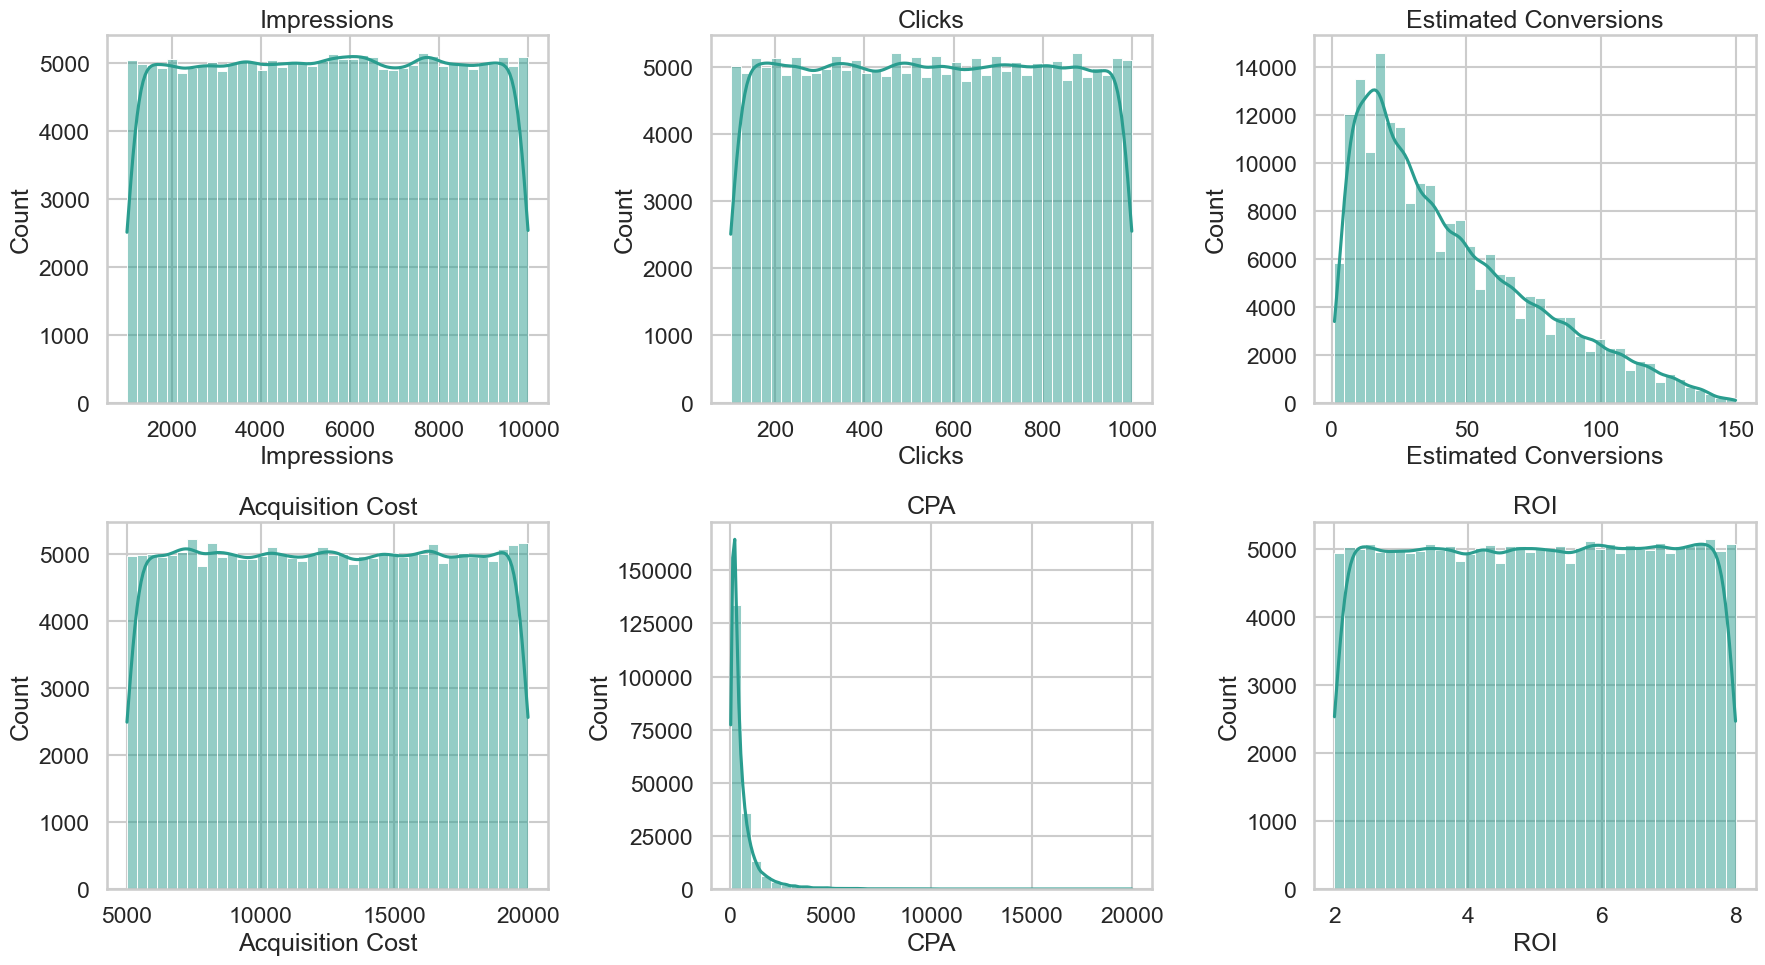

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

metric_order = [
    ("impressions", "Impressions"),
    ("clicks", "Clicks"),
    ("conversions", "Estimated Conversions"),
    ("acquisition_cost", "Acquisition Cost"),
    ("cpa", "CPA"),
    ("roi", "ROI"),
]

for axis, (column, title) in zip(axes.flat, metric_order):
    sns.histplot(df[column], bins=40, kde=True, ax=axis, color="#2a9d8f")
    axis.set_title(title)
    axis.set_xlabel(title)

plt.tight_layout()
plt.show()


## Bivariate / Multivariate Analysis

These plots focus on how efficiency metrics move together. Because the workbook contains more than 200,000 campaigns, the scatter plots use a reproducible sample for readability.


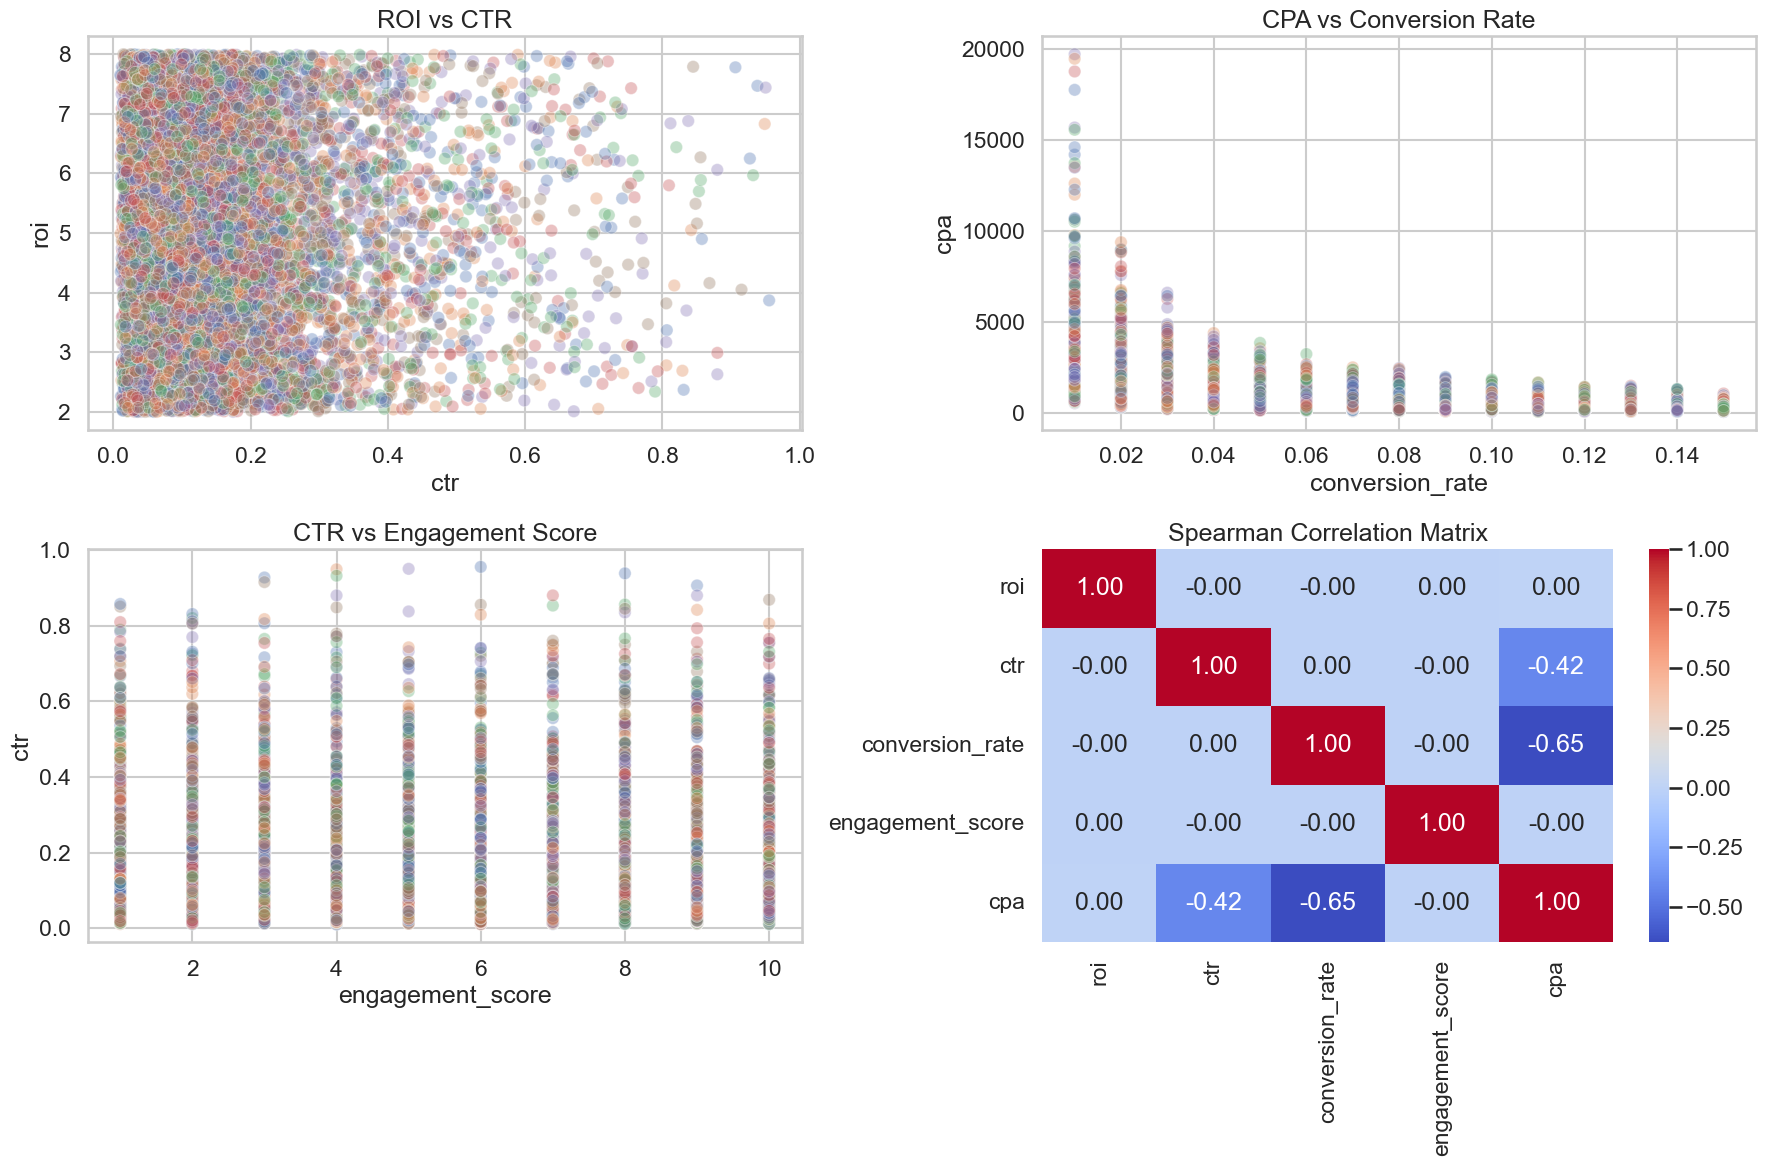

,roi,ctr,conversion_rate,engagement_score,cpa
roi,1.000,-0.002,-0.001,0.001,0.003
ctr,-0.002,1.000,0.001,-0.004,-0.418
conversion_rate,-0.001,0.001,1.000,-0.001,-0.649
engagement_score,0.001,-0.004,-0.001,1.000,-0.000
cpa,0.003,-0.418,-0.649,-0.000,1.000


In [7]:
sampled = df.sample(min(len(df), 12000), random_state=42)
spearman_corr = df[["roi", "ctr", "conversion_rate", "engagement_score", "cpa"]].corr(method="spearman")

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

sns.scatterplot(data=sampled, x="ctr", y="roi", hue="channel_used", alpha=0.35, ax=axes[0, 0], legend=False)
axes[0, 0].set_title("ROI vs CTR")

sns.scatterplot(data=sampled, x="conversion_rate", y="cpa", hue="campaign_type", alpha=0.35, ax=axes[0, 1], legend=False)
axes[0, 1].set_title("CPA vs Conversion Rate")

sns.scatterplot(data=sampled, x="engagement_score", y="ctr", hue="channel_used", alpha=0.35, ax=axes[1, 0], legend=False)
axes[1, 0].set_title("CTR vs Engagement Score")

sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[1, 1])
axes[1, 1].set_title("Spearman Correlation Matrix")

plt.tight_layout()
plt.show()
display(spearman_corr.round(3))


## Channel Performance

Channel-level aggregation answers whether performance differences come from media choice or whether channels look broadly interchangeable once campaigns are scaled up.


,channel_used,campaigns,spend,impressions,clicks,conversions,avg_roi,avg_engagement,ctr,conversion_rate,cpa
1,Facebook,32820,410603426,180662496,18038175,1446343,5.019,5.504,0.100,0.080,283.891
4,Website,33361,416606897,183815901,18415351,1477696,5.014,5.509,0.100,0.080,281.930
2,Google Ads,33440,418944514,185020154,18342589,1468777,5.003,5.494,0.099,0.080,285.234
0,Email,33599,420874104,184801107,18493963,1485425,4.996,5.488,0.100,0.080,283.336
5,YouTube,33393,416797090,183450845,18350935,1463702,4.994,5.485,0.100,0.080,284.755
3,Instagram,33392,417124850,183738455,18316654,1462938,4.989,5.489,0.100,0.080,285.128


C:\Users\ahmad\AppData\Local\Temp\ipykernel_2100\3430403203.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_summary.sort_values("avg_roi", ascending=False), x="channel_used", y="avg_roi", ax=axes[0], palette="crest")
C:\Users\ahmad\AppData\Local\Temp\ipykernel_2100\3430403203.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=channel_summary.sort_values("cpa"), x="channel_used", y="cpa", ax=axes[1], palette="flare")


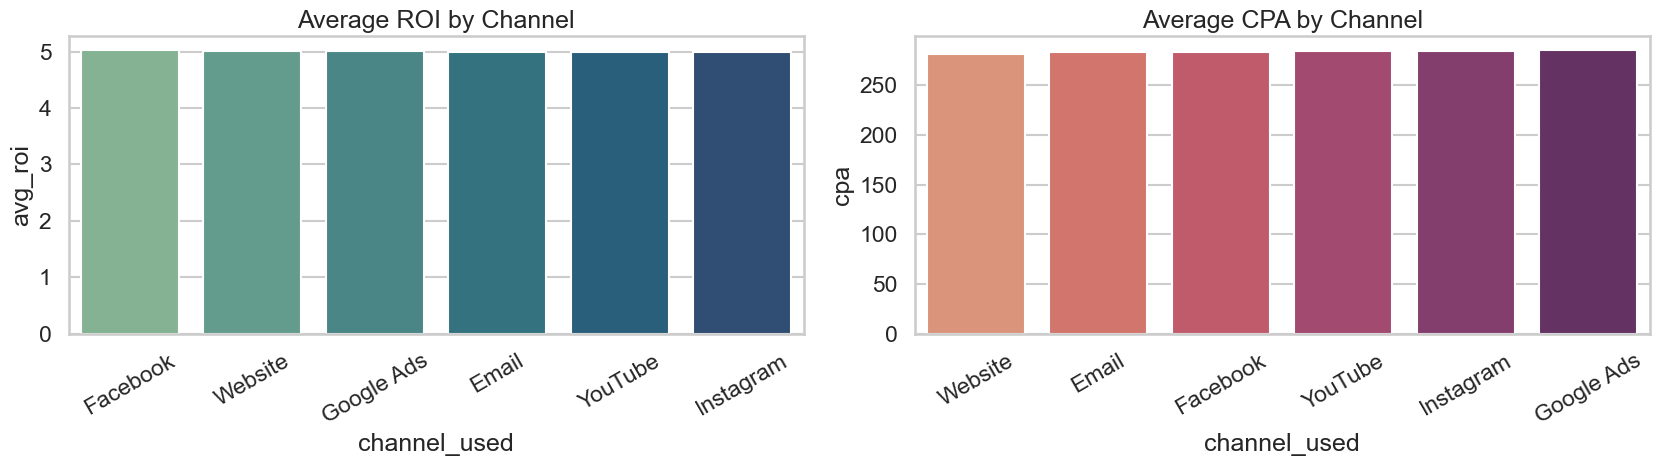

In [8]:
channel_summary = (
    df.groupby("channel_used")
    .agg(
        campaigns=("campaign_id", "count"),
        spend=("acquisition_cost", "sum"),
        impressions=("impressions", "sum"),
        clicks=("clicks", "sum"),
        conversions=("conversions", "sum"),
        avg_roi=("roi", "mean"),
        avg_engagement=("engagement_score", "mean"),
    )
    .reset_index()
)

channel_summary["ctr"] = channel_summary["clicks"] / channel_summary["impressions"]
channel_summary["conversion_rate"] = channel_summary["conversions"] / channel_summary["clicks"]
channel_summary["cpa"] = channel_summary["spend"] / channel_summary["conversions"]

display(channel_summary.sort_values("avg_roi", ascending=False).round(3))

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
sns.barplot(data=channel_summary.sort_values("avg_roi", ascending=False), x="channel_used", y="avg_roi", ax=axes[0], palette="crest")
axes[0].set_title("Average ROI by Channel")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=channel_summary.sort_values("cpa"), x="channel_used", y="cpa", ax=axes[1], palette="flare")
axes[1].set_title("Average CPA by Channel")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## Campaign Type Performance

Campaign type highlights whether the objective of the campaign itself is a stronger driver than the distribution channel.


,campaign_type,campaigns,spend,impressions,clicks,conversions,avg_roi,avg_engagement,ctr,conversion_rate,cpa
2,Influencer,40170,502419033,220771844,22038185,1771318,5.011,5.483,0.100,0.080,283.641
3,Search,40157,501911760,221415139,22032144,1764235,5.008,5.487,0.100,0.080,284.493
0,Display,39988,500177139,220080744,22031837,1763814,5.006,5.506,0.100,0.080,283.577
1,Email,39871,498197617,220147995,21898130,1747014,4.994,5.500,0.099,0.080,285.171
4,Social Media,39819,498245332,219073236,21957371,1758500,4.992,5.498,0.100,0.080,283.335


C:\Users\ahmad\AppData\Local\Temp\ipykernel_2100\2133376473.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_summary.sort_values("avg_roi", ascending=False), x="campaign_type", y="avg_roi", ax=axes[0], palette="viridis")
C:\Users\ahmad\AppData\Local\Temp\ipykernel_2100\2133376473.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=type_summary.sort_values("ctr", ascending=False), x="campaign_type", y="ctr", ax=axes[1], palette="mako")


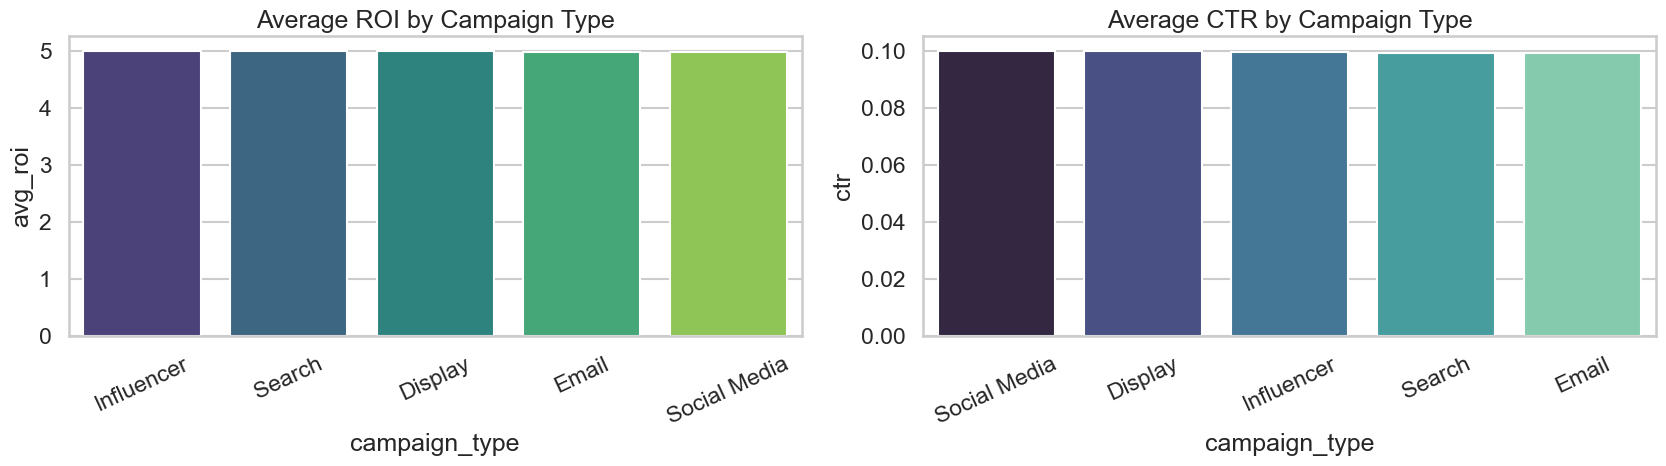

In [9]:
type_summary = (
    df.groupby("campaign_type")
    .agg(
        campaigns=("campaign_id", "count"),
        spend=("acquisition_cost", "sum"),
        impressions=("impressions", "sum"),
        clicks=("clicks", "sum"),
        conversions=("conversions", "sum"),
        avg_roi=("roi", "mean"),
        avg_engagement=("engagement_score", "mean"),
    )
    .reset_index()
)

type_summary["ctr"] = type_summary["clicks"] / type_summary["impressions"]
type_summary["conversion_rate"] = type_summary["conversions"] / type_summary["clicks"]
type_summary["cpa"] = type_summary["spend"] / type_summary["conversions"]

display(type_summary.sort_values("avg_roi", ascending=False).round(3))

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
sns.barplot(data=type_summary.sort_values("avg_roi", ascending=False), x="campaign_type", y="avg_roi", ax=axes[0], palette="viridis")
axes[0].set_title("Average ROI by Campaign Type")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(data=type_summary.sort_values("ctr", ascending=False), x="campaign_type", y="ctr", ax=axes[1], palette="mako")
axes[1].set_title("Average CTR by Campaign Type")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


## Date And Trend Analysis

Time patterns matter because campaigns can look strong simply by launching in favorable weeks or months. This section checks whether performance materially changes across the year.


,month_num,month_name,spend,clicks,conversions,avg_ctr,avg_conversion_rate,avg_cpa,avg_roi
0,1,Jan,212316141,9321651,748454,0.141,0.080,645.485,5.022
1,2,Feb,191592480,8433098,674491,0.142,0.080,634.340,5.018
2,3,Mar,212082085,9357568,749646,0.140,0.080,633.635,5.002
3,4,Apr,204473197,9009556,720985,0.141,0.080,634.323,4.998
4,5,May,212087084,9322143,746122,0.140,0.080,649.386,4.999
5,6,Jun,205374592,8997912,719226,0.138,0.080,642.061,5.006
6,7,Jul,212437111,9289500,746241,0.140,0.080,643.792,4.985
7,8,Aug,213172936,9362504,746362,0.140,0.080,645.816,4.976
8,9,Sep,205934708,9076880,725126,0.140,0.080,643.018,5.016
9,10,Oct,212767720,9387524,752016,0.141,0.080,638.796,5.002


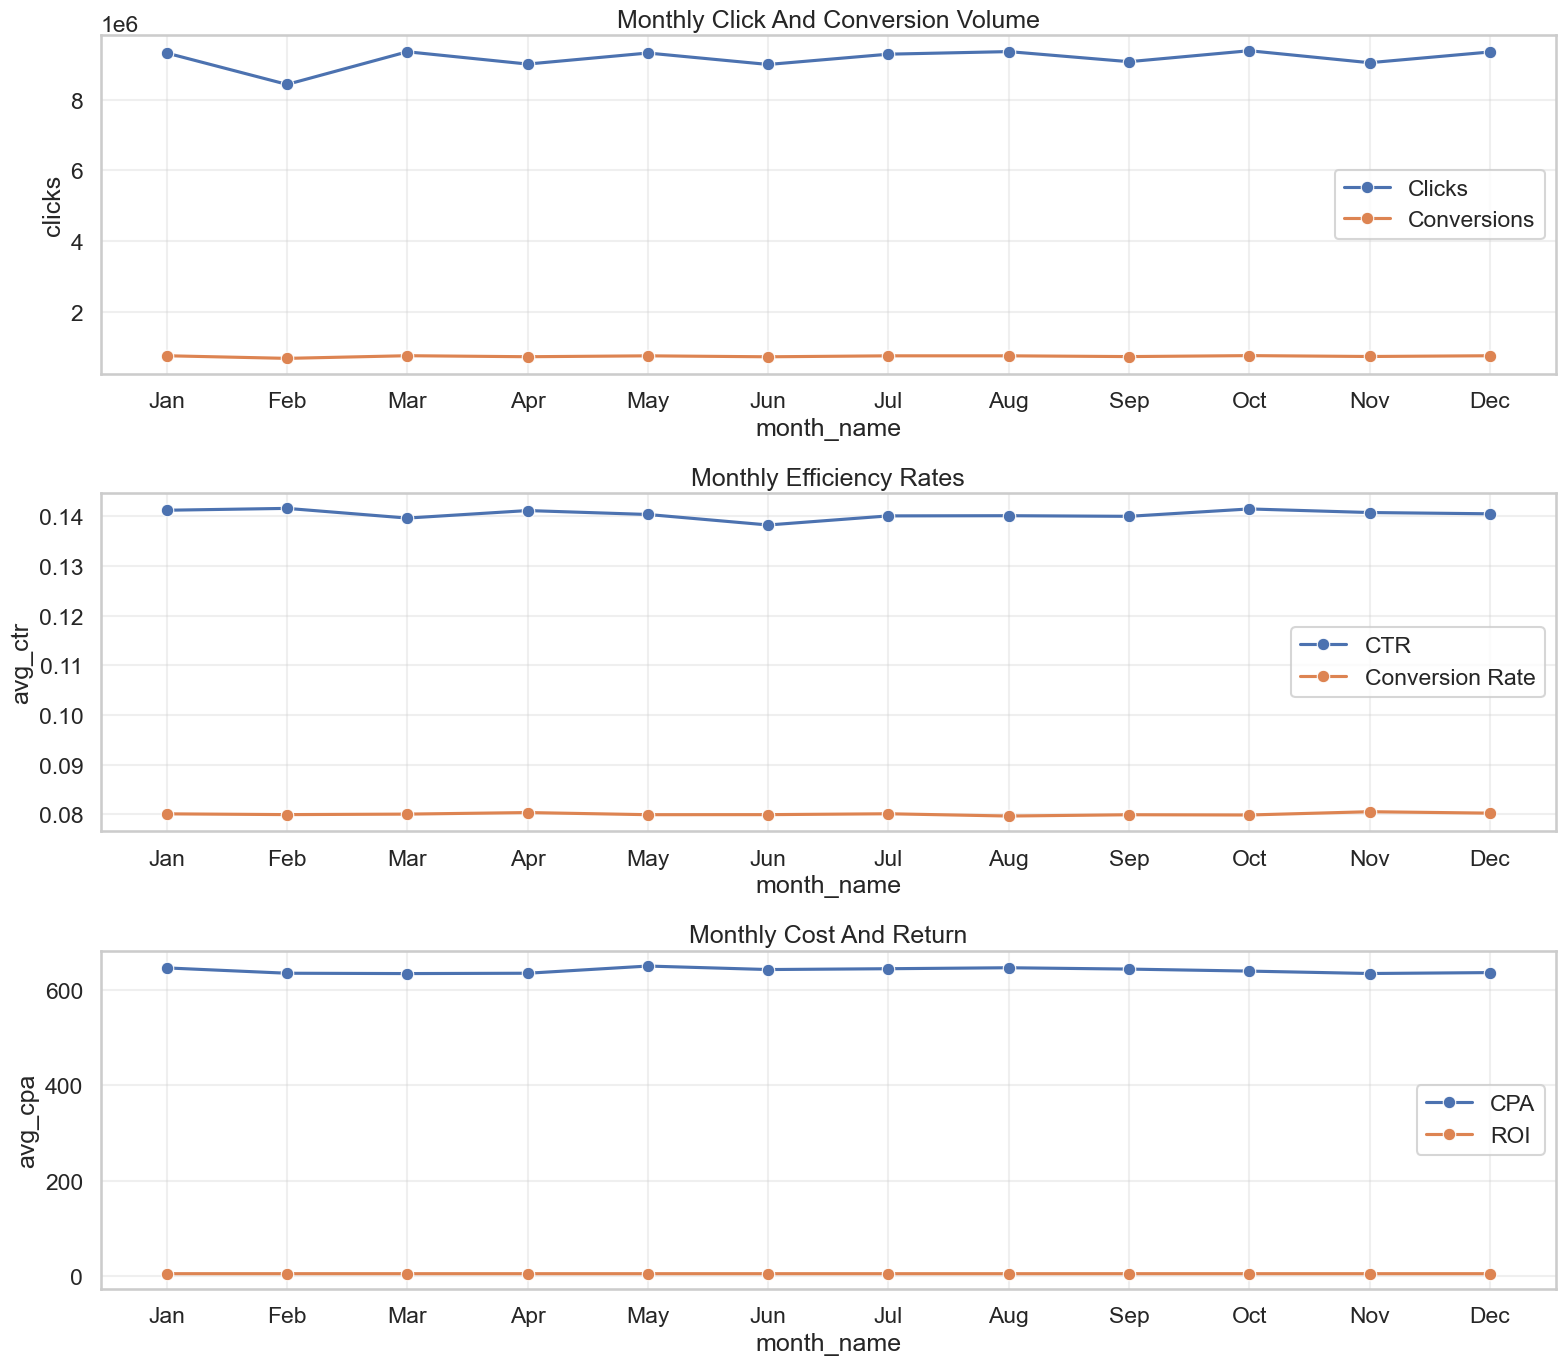

In [10]:
monthly_summary = (
    df.groupby(["month_num", "month_name"])
    .agg(
        spend=("acquisition_cost", "sum"),
        clicks=("clicks", "sum"),
        conversions=("conversions", "sum"),
        avg_ctr=("ctr", "mean"),
        avg_conversion_rate=("conversion_rate", "mean"),
        avg_cpa=("cpa", "mean"),
        avg_roi=("roi", "mean"),
    )
    .reset_index()
    .sort_values("month_num")
)

display(monthly_summary.round(3))

fig, axes = plt.subplots(3, 1, figsize=(16, 14))

sns.lineplot(data=monthly_summary, x="month_name", y="clicks", marker="o", ax=axes[0], label="Clicks")
sns.lineplot(data=monthly_summary, x="month_name", y="conversions", marker="o", ax=axes[0], label="Conversions")
axes[0].set_title("Monthly Click And Conversion Volume")

sns.lineplot(data=monthly_summary, x="month_name", y="avg_ctr", marker="o", ax=axes[1], label="CTR")
sns.lineplot(data=monthly_summary, x="month_name", y="avg_conversion_rate", marker="o", ax=axes[1], label="Conversion Rate")
axes[1].set_title("Monthly Efficiency Rates")

sns.lineplot(data=monthly_summary, x="month_name", y="avg_cpa", marker="o", ax=axes[2], label="CPA")
sns.lineplot(data=monthly_summary, x="month_name", y="avg_roi", marker="o", ax=axes[2], label="ROI")
axes[2].set_title("Monthly Cost And Return")

for axis in axes:
    axis.grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Feature-Specific Insights

Segment analysis checks whether the data suggests specific customer groups or audience clusters respond better, or whether campaign quality overwhelms segment differences.


,customer_segment,campaigns,avg_roi,avg_ctr,avg_conversion_rate,avg_cpa
1,Foodies,40210,5.004,0.141,0.080,643.288
4,Tech Enthusiasts,40154,5.004,0.141,0.080,637.937
2,Health & Wellness,39888,5.003,0.140,0.080,642.716
0,Fashionistas,39742,5.001,0.140,0.080,638.019
3,Outdoor Adventurers,40011,4.999,0.140,0.080,638.387


C:\Users\ahmad\AppData\Local\Temp\ipykernel_2100\3147019044.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary.sort_values("avg_conversion_rate", ascending=False), x="customer_segment", y="avg_conversion_rate", ax=axes[0], palette="cubehelix")
C:\Users\ahmad\AppData\Local\Temp\ipykernel_2100\3147019044.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=segment_summary.sort_values("avg_cpa"), x="customer_segment", y="avg_cpa", ax=axes[1], palette="rocket")


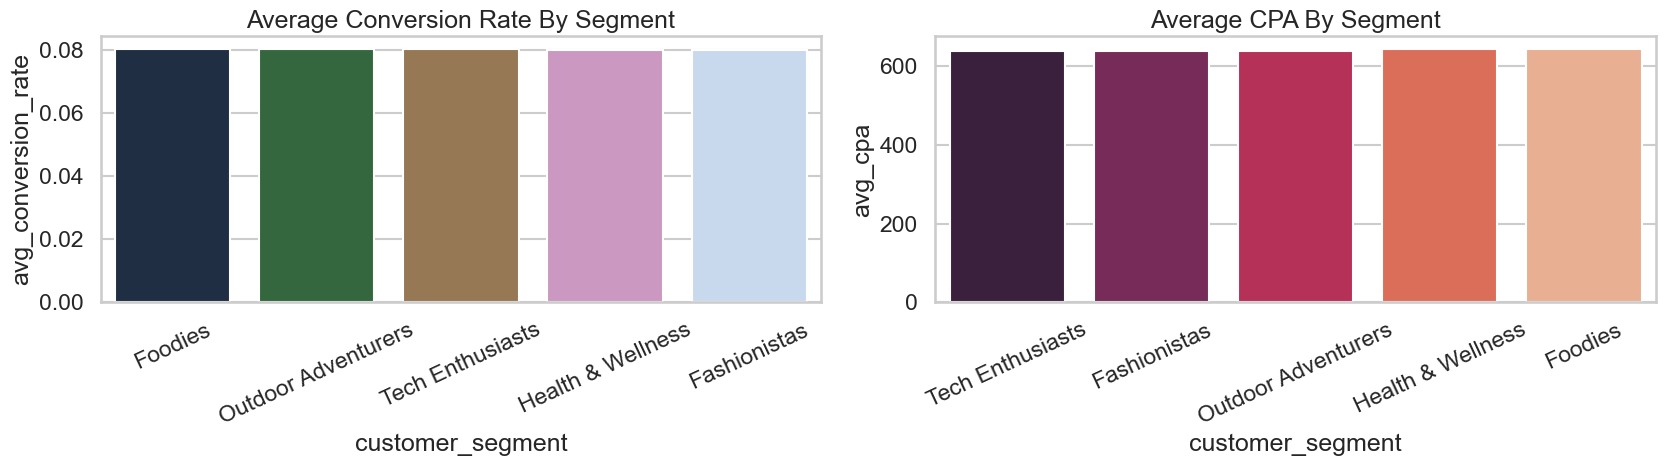

In [11]:
segment_summary = (
    df.groupby("customer_segment")
    .agg(
        campaigns=("campaign_id", "count"),
        avg_roi=("roi", "mean"),
        avg_ctr=("ctr", "mean"),
        avg_conversion_rate=("conversion_rate", "mean"),
        avg_cpa=("cpa", "mean"),
    )
    .reset_index()
    .sort_values("avg_roi", ascending=False)
)

display(segment_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
sns.barplot(data=segment_summary.sort_values("avg_conversion_rate", ascending=False), x="customer_segment", y="avg_conversion_rate", ax=axes[0], palette="cubehelix")
axes[0].set_title("Average Conversion Rate By Segment")
axes[0].tick_params(axis="x", rotation=25)

sns.barplot(data=segment_summary.sort_values("avg_cpa"), x="customer_segment", y="avg_cpa", ax=axes[1], palette="rocket")
axes[1].set_title("Average CPA By Segment")
axes[1].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


## Fair Campaign Comparison Logic

Ranking campaigns on raw ROI alone is weak here because ROI is very tightly distributed. A fairer scoreboard uses a median-activity filter plus a weighted effectiveness score built from ROI, conversion rate, CTR, engagement score, and inverse CPA.


In [12]:
fair_pool = df[(df["impressions"] >= df["impressions"].median()) & (df["clicks"] >= df["clicks"].median())].copy()

leaderboard_columns = [
    "campaign_id",
    "company",
    "channel_used",
    "campaign_type",
    "date",
    "impressions",
    "clicks",
    "conversions",
    "ctr",
    "conversion_rate",
    "cpa",
    "roi",
    "effectiveness_score",
]

display(
    fair_pool.nlargest(15, "effectiveness_score")[leaderboard_columns].round(
        {
            "ctr": 4,
            "conversion_rate": 4,
            "cpa": 2,
            "roi": 2,
            "effectiveness_score": 2,
        }
    )
)

top_quartile = df[df["effectiveness_score"] >= df["effectiveness_score"].quantile(0.75)]
bottom_quartile = df[df["effectiveness_score"] <= df["effectiveness_score"].quantile(0.25)]

driver_profile = pd.DataFrame(
    {
        "top_quartile": [
            top_quartile["roi"].mean(),
            top_quartile["ctr"].mean(),
            top_quartile["conversion_rate"].mean(),
            top_quartile["cpa"].mean(),
            top_quartile["engagement_score"].mean(),
            top_quartile["duration_days"].mean(),
            top_quartile["clicks"].mean(),
            top_quartile["impressions"].mean(),
        ],
        "bottom_quartile": [
            bottom_quartile["roi"].mean(),
            bottom_quartile["ctr"].mean(),
            bottom_quartile["conversion_rate"].mean(),
            bottom_quartile["cpa"].mean(),
            bottom_quartile["engagement_score"].mean(),
            bottom_quartile["duration_days"].mean(),
            bottom_quartile["clicks"].mean(),
            bottom_quartile["impressions"].mean(),
        ],
    },
    index=[
        "roi",
        "ctr",
        "conversion_rate",
        "cpa",
        "engagement_score",
        "duration_days",
        "clicks",
        "impressions",
    ],
)

top_channel_share = (100 * top_quartile["channel_used"].value_counts(normalize=True)).round(2).rename("top_quartile_share_pct")
top_type_share = (100 * top_quartile["campaign_type"].value_counts(normalize=True)).round(2).rename("top_quartile_share_pct")

display(driver_profile.round(3))
display(top_channel_share.to_frame())
display(top_type_share.to_frame())


,campaign_id,company,channel_used,campaign_type,date,impressions,clicks,conversions,ctr,conversion_rate,cpa,roi,effectiveness_score
45125,45126,TechCorp,Instagram,Search,2021-08-19,6933,969,145,0.140,0.150,101.630,7.990,91.710
106821,106822,NexGen Systems,Email,Email,2021-08-30,6076,981,147,0.162,0.150,102.660,7.860,91.110
196038,196039,DataTech Solutions,Facebook,Search,2021-03-02,6653,841,126,0.126,0.150,65.970,7.920,90.980
39482,39483,Alpha Innovations,Email,Social Media,2021-04-03,5899,883,132,0.150,0.150,102.470,7.920,90.860
190415,190416,NexGen Systems,Email,Search,2021-08-09,6350,1000,140,0.158,0.140,55.990,7.780,90.810
163617,163618,NexGen Systems,Instagram,Influencer,2021-08-04,6843,996,149,0.146,0.150,56.050,7.780,90.520
12617,12618,DataTech Solutions,Instagram,Social Media,2021-07-27,6449,995,149,0.154,0.150,110.850,7.820,90.360
43166,43167,Innovate Industries,Instagram,Display,2021-07-04,5750,846,118,0.147,0.140,101.650,7.890,90.240
81940,81941,NexGen Systems,Instagram,Social Media,2021-06-30,6421,986,138,0.154,0.140,83.010,7.930,90.150
41064,41065,DataTech Solutions,Google Ads,Search,2021-04-07,7713,965,145,0.125,0.150,79.990,7.820,90.100


,top_quartile,bottom_quartile
roi,6.467,3.559
ctr,0.202,0.087
conversion_rate,0.110,0.049
cpa,213.568,"1,294.919"
engagement_score,6.138,4.850
duration_days,37.538,37.510
clicks,665.571,429.447
impressions,"4,659.425","6,266.302"


,top_quartile_share_pct
channel_used,
Email,16.930
Website,16.880
Google Ads,16.780
Facebook,16.570
Instagram,16.470
YouTube,16.360


,top_quartile_share_pct
campaign_type,
Influencer,20.320
Display,20.170
Search,20.080
Social Media,19.760
Email,19.670


## Statistical Checks

Large marketing tables can make tiny differences look important. This section explicitly tests whether average ROI differs across channels or campaign types and reports effect size, not only p-values.


In [13]:
channel_groups = [group["roi"].values for _, group in df.groupby("channel_used")]
type_groups = [group["roi"].values for _, group in df.groupby("campaign_type")]

channel_h, channel_p = stats.kruskal(*channel_groups)
type_h, type_p = stats.kruskal(*type_groups)

channel_k = len(channel_groups)
type_k = len(type_groups)
n = len(df)

channel_epsilon_sq = (channel_h - channel_k + 1) / (n - channel_k)
type_epsilon_sq = (type_h - type_k + 1) / (n - type_k)

stats_summary = pd.DataFrame(
    {
        "comparison": ["ROI by channel", "ROI by campaign type"],
        "kruskal_h": [channel_h, type_h],
        "p_value": [channel_p, type_p],
        "epsilon_squared": [channel_epsilon_sq, type_epsilon_sq],
    }
)

display(stats_summary.round(6))
display(df[["roi", "ctr", "conversion_rate", "engagement_score", "cpa"]].corr(method="spearman").round(3))


,comparison,kruskal_h,p_value,epsilon_squared
0,ROI by channel,7.708,0.173,0.000
1,ROI by campaign type,4.059,0.398,0.000


,roi,ctr,conversion_rate,engagement_score,cpa
roi,1.000,-0.002,-0.001,0.001,0.003
ctr,-0.002,1.000,0.001,-0.004,-0.418
conversion_rate,-0.001,0.001,1.000,-0.001,-0.649
engagement_score,0.001,-0.004,-0.001,1.000,-0.000
cpa,0.003,-0.418,-0.649,-0.000,1.000


## Visual Analysis

The final visuals summarize whether channel performance changes materially month to month and whether the best-looking channels combine strong CTR and ROI without paying for it through high CPA.


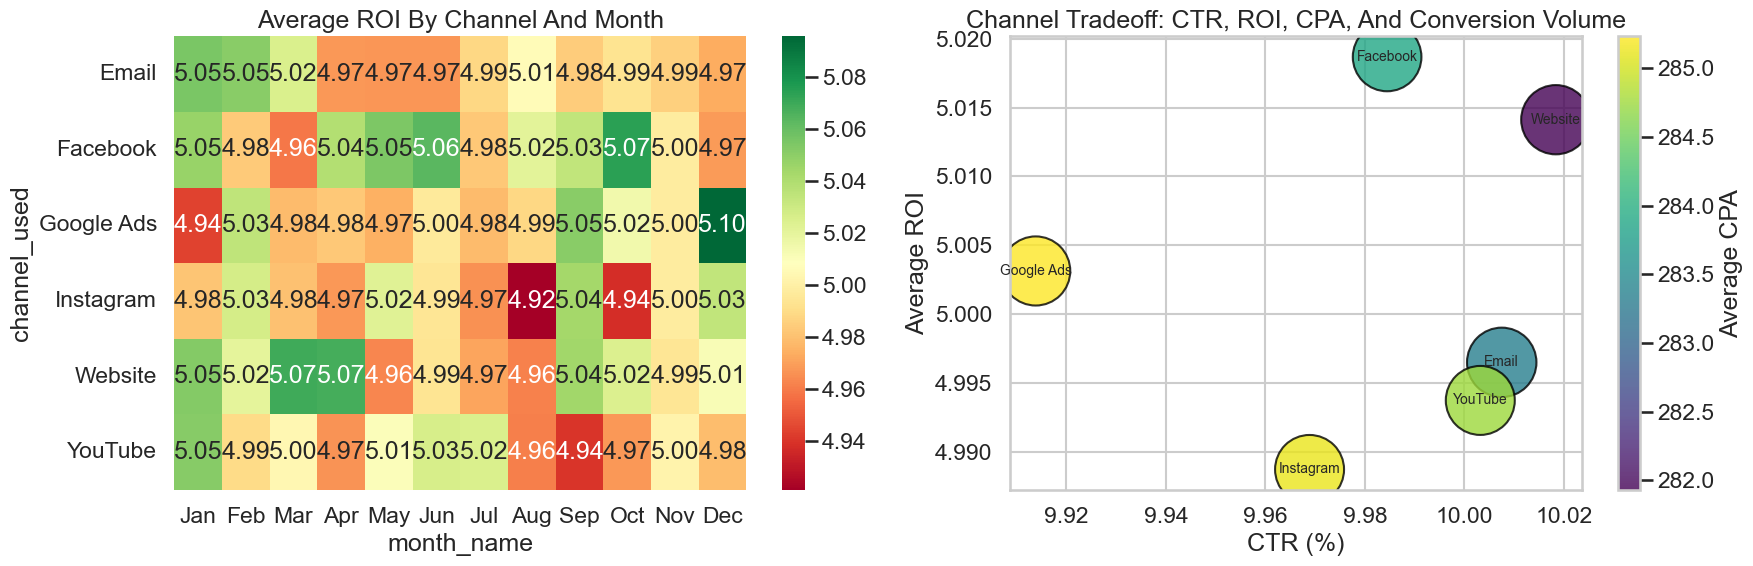

In [14]:
month_order = monthly_summary["month_name"].tolist()
roi_heatmap = df.pivot_table(index="channel_used", columns="month_name", values="roi", aggfunc="mean")
roi_heatmap = roi_heatmap[month_order]

bubble = channel_summary.copy()
bubble_sizes = 300 + 2200 * bubble["conversions"] / bubble["conversions"].max()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.heatmap(roi_heatmap, annot=True, fmt=".2f", cmap="RdYlGn", ax=axes[0])
axes[0].set_title("Average ROI By Channel And Month")

scatter = axes[1].scatter(
    bubble["ctr"] * 100,
    bubble["avg_roi"],
    s=bubble_sizes,
    c=bubble["cpa"],
    cmap="viridis",
    alpha=0.8,
    edgecolor="black",
)
for _, row in bubble.iterrows():
    axes[1].text(row["ctr"] * 100, row["avg_roi"], row["channel_used"], ha="center", va="center", fontsize=10)

axes[1].set_xlabel("CTR (%)")
axes[1].set_ylabel("Average ROI")
axes[1].set_title("Channel Tradeoff: CTR, ROI, CPA, And Conversion Volume")
plt.colorbar(scatter, ax=axes[1], label="Average CPA")

plt.tight_layout()
plt.show()


## Key Findings

- Channel ROI is almost flat. Facebook is the top mean-ROI channel at about `5.02`, but the spread across channels is tiny and not statistically meaningful in a practical sense.
- Website and Email are the cheapest scaled channels on CPA, while Google Ads is the most expensive. The absolute gap is still modest relative to the dataset size.
- Top-quartile campaigns win through execution quality, not longer duration. They deliver roughly `20.2%` CTR versus `8.7%` for the bottom quartile, `11.0%` versus `4.9%` conversion rate, and about `$214` CPA versus `$1,295`.
- Bottom-quartile campaigns often buy more impressions but convert that attention poorly. Strong campaigns generate more clicks from fewer impressions, which implies better targeting or creative relevance.
- Channel and campaign-type shares in the top quartile are nearly even, so no single channel monopolizes top performers. The data points to operational quality inside campaigns rather than a simple "pick this channel" answer.
- Monthly trends are stable throughout 2021. The dataset does not show a strong seasonal spike that would explain winners by timing alone.


## Limitations

- The workbook is read from a public raw GitHub URL unless a local copy is provided, so notebook execution depends on network availability.
- Conversions are inferred from `Clicks * Conversion_Rate`; they are not stored as a native column.
- `Acquisition_Cost` is treated as campaign spend. If the source defines it differently, CPC and CPA interpretations should be revisited.
- The metric structure looks highly standardized, which suggests the dataset may be synthetic or heavily normalized. That likely compresses real-world channel differences.


## Recommendations / Next Steps

- Prioritize campaigns that lift CTR and conversion rate together instead of optimizing reach alone.
- Use channel as a secondary optimization lever; the strongest improvements are more likely to come from targeting, offer quality, landing-page quality, and creative fit.
- Add guardrails that flag campaigns with high impressions but weak click quality or very high CPA.
- Track top-quartile design patterns by company, audience, and creative, then reuse those playbooks in future launches.
- If richer data becomes available, extend the notebook with native revenue, post-click funnel steps, and A/B test metadata.


## Common Mistakes

- Ranking campaigns on ROI alone when ROI barely varies across the table.
- Treating statistical significance as business significance in a very large sample.
- Assuming more impressions means better performance without checking CTR and CPA.
- Blaming weak campaigns on channel choice when the main gap comes from execution quality.


## Mini Challenge

Build a second leaderboard that weights ROI, CPA, and conversion rate differently for three stakeholder views: a growth lead, a finance lead, and a brand lead. Compare how the top 10 campaigns change under each weighting scheme.


## Final Summary

The workbook shows that campaign winners are not mainly explained by channel or calendar timing. The best campaigns combine stronger click quality, better post-click conversion, and sharply lower CPA. In short: top campaigns are effective because they turn attention into action more efficiently, not because they simply bought more reach.
